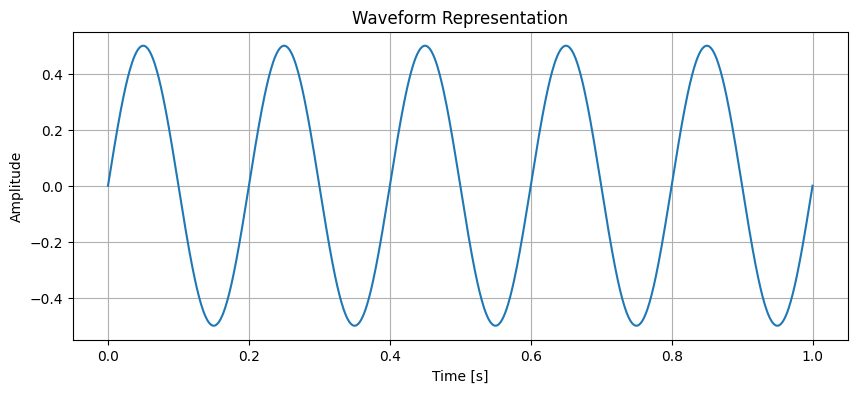

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a sample sound wave
fs = 1000  # Sampling frequency
t = np.linspace(0, 1, fs)  # Time vector
amplitude = 0.5 * np.sin(2 * np.pi * 5 * t)  # 5 Hz sine wave

# Plotting the waveform
plt.figure(figsize=(10, 4))
plt.plot(t, amplitude)
plt.title('Waveform Representation')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


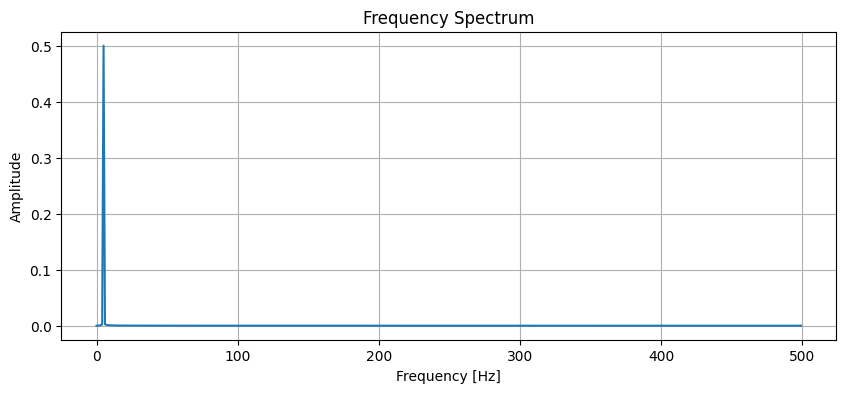

In [3]:
from scipy.fft import fft, fftfreq

# FFT of the signal
N = len(amplitude)
yf = fft(amplitude)
xf = fftfreq(N, 1/fs)

# Plotting the frequency spectrum
plt.figure(figsize=(10, 4))
plt.plot(xf[:N//2], 2.0/N * np.abs(yf[:N//2]))
plt.title('Frequency Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


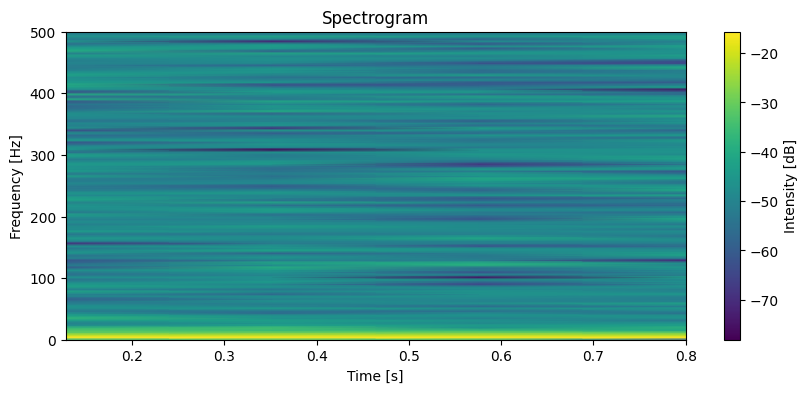

In [4]:
from scipy.signal import spectrogram

# Generate a sample sound signal
signal = amplitude + 0.1 * np.random.normal(size=t.shape)  # Adding noise

# Create the spectrogram
frequencies, times, Sxx = spectrogram(signal, fs)

# Plotting the spectrogram
plt.figure(figsize=(10, 4))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.title('Spectrogram')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.colorbar(label='Intensity [dB]')
plt.show()


In [5]:
!pip install librosa

You should consider upgrading via the '/Users/ngocp/Documents/projects/pyml/english-pronoun/myenv/bin/python -m pip install --upgrade pip' command.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import subprocess

In [8]:
file_path = '../uploads/recording.wav'
output_file = '../uploads/output.mp3'

In [ ]:


def verify_wav_file(file_path):
    command = ['ffmpeg', '-v', 'error', '-i', file_path, '-f', 'null', '-']
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise ValueError(f"Invalid WAV file: {result.stderr}")

def convert_wav_to_mp3(input_file, output_file):
    command = ['ffmpeg', '-i', input_file, output_file]
    subprocess.run(command, check=True)


In [9]:
# Verify the WAV file
# verify_wav_file(file_path)

# Convert the WAV file to MP3 format
# convert_wav_to_mp3(file_path, output_file)

/var/folders/g6/37kt02914kx36yzcbbqfyck00000gn/T/ipykernel_58667/2906481041.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)  # y is the audio time series, sr is the sample rate
/Users/ngocp/Documents/projects/pyml/english-pronoun/myenv/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


D: (1025, 670) [ 1.27009585e-01+0.j  1.81193680e-01+0.j  4.20477428e-02+0.j
  3.50369327e-02+0.j  1.30346818e-02+0.j -6.26873691e-03+0.j
 -6.93492545e-03+0.j -5.45447245e-02+0.j -3.43247913e-02+0.j
 -4.87337746e-02+0.j -2.09607556e-03+0.j  2.54555289e-02+0.j
  2.13005915e-02+0.j  6.90040644e-03+0.j -4.72505167e-02+0.j
 -6.19706586e-02+0.j -3.89232226e-02+0.j -2.87283584e-02+0.j
 -1.40889231e-02+0.j -2.08119322e-02+0.j -5.88489473e-02+0.j
 -4.32717130e-02+0.j -2.76146713e-03+0.j -1.78330839e-02+0.j
  1.50034558e-02+0.j  6.62722811e-02+0.j -1.55870349e-03+0.j
 -4.18075584e-02+0.j -2.41222456e-02+0.j -9.73935518e-03+0.j
 -1.03339879e-02+0.j -4.71583679e-02+0.j -7.20186606e-02+0.j
 -8.61553922e-02+0.j -4.51299958e-02+0.j  2.30211802e-02+0.j
  3.42016555e-02+0.j  2.99291629e-02+0.j  1.06433388e-02+0.j
  4.17234097e-03+0.j  3.28476867e-03+0.j -9.85090621e-03+0.j
  5.38108358e-03+0.j  1.88902300e-03+0.j -9.71966330e-03+0.j
 -1.41685857e-02+0.j  3.83159553e-04+0.j  1.20600807e-02+0.j
  5.84862

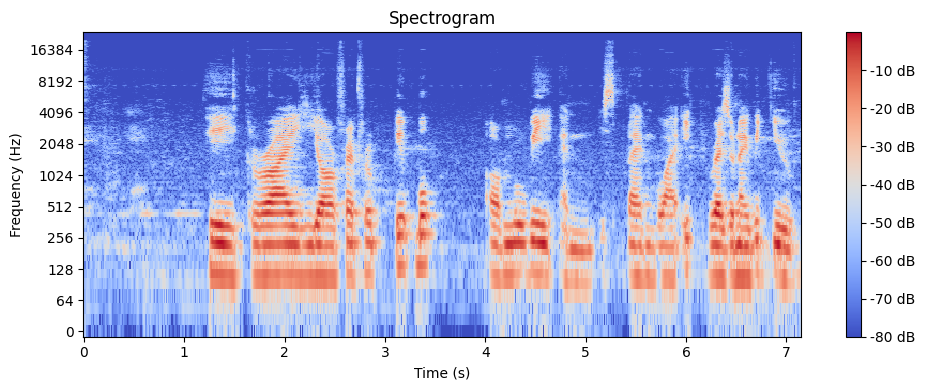

In [10]:
y, sr = librosa.load(file_path, sr=None)  # y is the audio time series, sr is the sample rate

# Compute the Short-Time Fourier Transform (STFT)
D = librosa.stft(y)  # Compute the STFT
print('D:', D.shape, D[0])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)  # Convert to decibels

# Plot the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', cmap='coolwarm')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.tight_layout()
plt.show()
